In [ ]:
%pip install -r requirements.txt

In [ ]:
#実験１
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = "../data/outlier_deal_for_nan_exp1.csv"
df = pd.read_csv(path)

In [1]:
#実験２
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = "../data/outlier_deal_for_nan_exp2.csv"
df = pd.read_csv(path)

### 前処理のための閾値探索
#### 95%タイル値から上を外れ値とし、対象参加者の回答を無効で進める()

In [10]:
response_id = "R_9OwRUAA1BoKmvhl"
target_col = "frame_choice"

##### 個別分析 - R_9OwRUAA1BoKmvhlの回答値

In [6]:
distribution = (
    df
    .groupby("responseId")[target_col]
    .value_counts(dropna=False)
    .rename("count")
    .reset_index()
    .sort_values("count", ascending=False)
)

distribution

,responseId,Affect Level,count
1797,R_9OwRUAA1BoKmvhl,70.0,90
2032,R_9dukvbnZkwMhA8D,50.0,83
1974,R_9d3P33wTPvC95vK,50.0,67
1286,R_98CCmrZLuPem2Z1,100.0,55
0,R_406piivDmShdVkR,60.0,54
...,...,...,...
2369,R_9woU6R56NCDoD6B,55.0,1
2370,R_9woU6R56NCDoD6B,82.0,1
2371,R_9woU6R56NCDoD6B,45.0,1
2372,R_9woU6R56NCDoD6B,66.0,1


#### 最大出現回数カウントし、パーセンタイルを出す

In [3]:
target_col = "frame_choice"

In [11]:
# Affect Level 及び　Alertness Levelの処理 (Water Level)

max_counts = (
    df
    .groupby("responseId")[target_col]
    .value_counts()
    .groupby(level=0)
    .max()
    .rename("max_count")
    .reset_index()
    .sort_values("max_count", ascending=False)
)

max_counts

,responseId,max_count
25,R_4bUjETzToKoQGPC,59
61,R_9KvVFr4rSnSdni9,46
42,R_4zvg1Lm9KuCLCYK,42
48,R_94IaaaoUWpDUOnZ,42
38,R_4uDiIE5PojtreCt,39
...,...,...
33,R_4m9wZgsavOjV2op,5
86,R_9vBA5sYmKdO1rGh,5
15,R_4LXZoUimvCiNHXj,4
0,R_1dhGvBCKCdsLlbu,4


In [4]:
#Framechoice (Pagesubmit_fc)の処理

max_counts = (
    df
    .groupby("responseId")["frame_choice"]
    .value_counts()
    .groupby(level=0)
    .max()
    .div(5)
    .rename("max_count")
    .reset_index()
    .sort_values("max_count", ascending=False)
)

max_counts

,responseId,max_count
2,R_40pCpySLP6ZuI7M,20.0
6,R_42ipwOKu6U6BoXR,20.0
16,R_4MM0pFJzT4x7saJ,20.0
14,R_4KlP1gGv5YGH3cr,20.0
17,R_4Nnfb0Ln0BTZ70t,20.0
...,...,...
0,R_1dhGvBCKCdsLlbu,10.0
66,R_9P03J60atV7Jaxf,10.0
61,R_9KvVFr4rSnSdni9,10.0
74,R_9dZq3AcjktReIKd,10.0


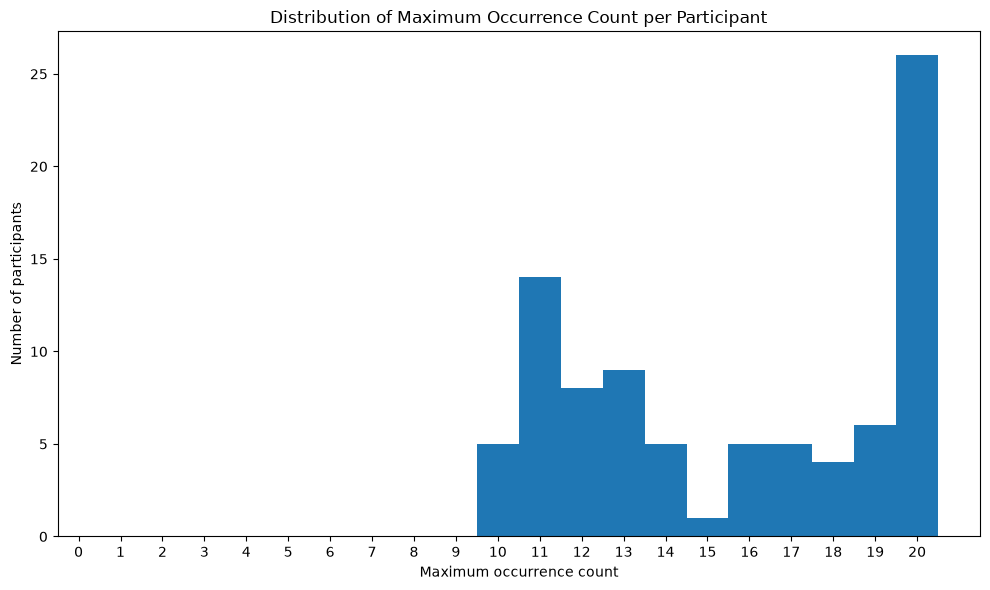

In [5]:
x = max_counts["max_count"]
xmax = int(x.max())

plt.figure(figsize=(10, 6))

plt.hist(x, bins=np.arange(0.5, xmax + 1.5, 1))

plt.xlabel("Maximum occurrence count")
plt.ylabel("Number of participants")
plt.title("Distribution of Maximum Occurrence Count per Participant")

# 目盛り間隔は最大値に応じて調整(目盛りが約20個以内に収まる)
step = max(1, int(np.ceil(xmax / 20)))
plt.xticks(np.arange(0, xmax + step, step))

plt.tight_layout()
plt.show()

In [6]:
print(x.shape)

(88,)


In [7]:
upper_95 = max_counts["max_count"].quantile(0.95)

print("95%点:", upper_95)

95%点: 20.0


#### 95%タイル値 実験1
- AffectLevel 49.79999... => **50**
- AlertnessLevel 90.3999... => **90**
- FrameChoice **100.0(20.0) 全回答同じ** => 無視か？　フレーム選択の回答に感情効果が影響なし、ともとれる

#### 95%タイル値 実験2
- AffectLevel 46.25... => **46**
- AlertnessLevel 60.25... => **60**
- FrameChoice **100.0(20.0) 全回答同じ** => 無視か？　フレーム選択の回答に感情効果が影響なし、ともとれる

### 以下全データにおいて95パーセンタイル検出&前処理

In [34]:
target_col = "Alertness Level"
threshold = 60

In [35]:
# responseIdごとに、各値の出現回数をカウント
counts = df.groupby("responseId")[target_col].value_counts()

# 各参加者の「最大出現回数」を取得
max_counts = counts.groupby(level=0).max()

# 最大出現回数が50以上のresponseId
target_response_ids = max_counts[max_counts >= threshold].index

print(target_col)
print("対象者数")
print(target_response_ids.size)
print("対象者ID")
print(target_response_ids)

Alertness Level
対象者数
5
対象者ID
Index(['R_4M2nNbp82pIAmOJ', 'R_4s5g2hV3Ym94UgH', 'R_9TMmpGaAsS8pxzB',
       'R_9scu1S8qhZLB7JT', 'R_9yDb9mGzgFuZLPP'],
      dtype='str', name='responseId')


#### 上記対象者IDを手書きで遡って basic_data_check_and_split.ipynbにて削除する